# **TUGAS KELOMPOK DATA WRANGLING**
### **Pre-Processing dan Klasifikasi Data Pasien ICU untuk Prediksi Kelangsungan Hidup Menggunakan Machine Learning** 

### A. Deskripsi Dataset
Dataset yang digunakan adalah **ICU Survival Prediction** dari **Kaggle**. Dataset berisi data pasien ICU yang digunakan untuk memprediksi apakah pasien dapat bertahan hidup selama perawatan di ICU.

Dataset yang digunakan adalah file:

train (6).csv 

Memiliki: 
1. 4.580 baris
2. 16 kolom
3. Variabel target/label **survived_icu** dengan nilai **0=pasien tidak selamat** dan **1=pasiem selamat**
4. Variabel input=informasi demografis dan kondisi klinis pasien, seperti umur, gender, BMI, denyut jantung, tekanan darah, saturasi oksigen, kadar glukosa, kreatinin, jumlah sel darah putih, tingkat keparahan penyakit, kebutuhan ventilator, dan jumlah kondisi kronis

### B. Tujuan Pre-Processing
1. Mengidentifikasi data yang hilang
2. Menangani missing value
3. Mengidentifikasi dan menangani outlier
4. Memastikan tidak terdapat data duplikat
5. Memisahkan fitur dan target 
6. Melakukan standardisasi data
7. Mempersiapkan dataset untuk supervised learning
8. Mengevaluasi kemampuan model dalam melakukan klasifikasi

Anggota Kelompok:
1. Ahdila Putri Tahta Rohma (269) 
2. Aulia Mayza Widianto (131)
3. Ibnu A. Zahran Latua (053) 

## 1. Import Library & Load Data

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("train (6).csv")
print("Ukuran data:", df.shape)
df.head()

Ukuran data: (4580, 16)


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
0,ICU_00301,51,1,20.0,78.6,128.3,67.1,13.7,92.4,40.0,2.98,1.45,14,0,1,1
1,ICU_05027,54,0,25.5,124.2,146.4,91.9,19.4,83.9,129.6,0.31,4.67,14,1,1,0
2,ICU_00475,57,0,27.6,124.7,127.6,78.3,10.4,100.0,274.0,4.37,10.32,24,1,1,0
3,ICU_04732,43,1,24.8,89.9,123.3,67.3,17.8,92.5,218.4,1.94,24.55,15,1,4,0
4,ICU_01889,61,0,21.4,96.1,187.0,71.6,25.1,86.2,126.5,0.37,8.47,3,0,1,1


## 2. Eksplorasi Awal (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            4580 non-null   str    
 1   age                   4580 non-null   int64  
 2   gender                4580 non-null   int64  
 3   bmi                   3959 non-null   float64
 4   heart_rate            4580 non-null   float64
 5   systolic_bp           4580 non-null   float64
 6   diastolic_bp          4580 non-null   float64
 7   respiratory_rate      4005 non-null   float64
 8   oxygen_saturation     3977 non-null   float64
 9   glucose               4580 non-null   float64
 10  creatinine            3939 non-null   float64
 11  wbc_count             3772 non-null   float64
 12  severity_score        4580 non-null   int64  
 13  ventilation_required  4580 non-null   int64  
 14  chronic_conditions    4580 non-null   int64  
 15  survived_icu          4580 non-n

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4580.0,61.436245,17.154096,18.0,50.000,62.00,73.0000,95.000000
gender,4580.0,0.532096,0.499023,0.0,0.000,1.00,1.0000,1.000000
bmi,3959.0,27.009093,7.507568,9.0,21.600,26.40,31.7000,57.000000
heart_rate,4580.0,99.210786,84.479186,30.0,73.900,89.00,103.7000,1207.839980
systolic_bp,4580.0,133.573375,117.907364,60.0,98.600,118.30,138.8000,1645.595945
diastolic_bp,4580.0,71.957969,17.337162,30.0,59.800,72.20,83.8000,130.000000
respiratory_rate,4005.0,18.061673,5.886609,6.0,13.900,18.00,22.1000,37.300000
oxygen_saturation,3977.0,94.565954,4.385576,78.4,91.700,95.00,98.4000,100.000000
glucose,4580.0,159.452983,156.701082,40.0,99.775,141.10,183.8250,2256.210085
creatinine,3939.0,1.373065,1.828402,0.3,0.360,0.89,1.7500,48.737770


survived_icu
1    2948
0    1632
Name: count, dtype: int64
survived_icu
1    0.644
0    0.356
Name: proportion, dtype: float64


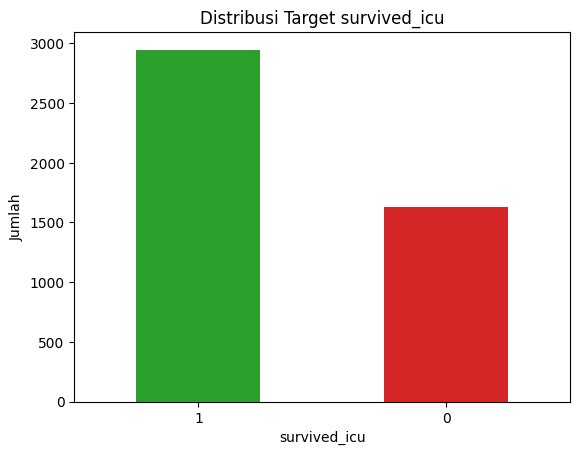

In [5]:
print(df["survived_icu"].value_counts())
print(df["survived_icu"].value_counts(normalize=True).round(3))

df["survived_icu"].value_counts().plot(kind="bar", color=["tab:green", "tab:red"])
plt.title("Distribusi Target survived_icu")
plt.xlabel("survived_icu")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

In [6]:
# Korelasi fitur dengan target (untuk tahu kolom mana yang benar-benar punya sinyal)
df.drop(columns="patient_id").corr()["survived_icu"].drop("survived_icu").sort_values().round(3)

age                    -0.211
severity_score         -0.148
ventilation_required   -0.064
chronic_conditions     -0.064
diastolic_bp           -0.023
respiratory_rate       -0.020
creatinine             -0.011
gender                 -0.005
wbc_count              -0.003
systolic_bp            -0.002
heart_rate              0.000
glucose                 0.003
bmi                     0.023
oxygen_saturation       0.039
Name: survived_icu, dtype: float64

## 3. Identifikasi Masalah pada Data

Ada 5 kategori masalah yang diperiksa: **missing value, duplikat, outlier, nilai tidak logis (domain knowledge)**, dan **capping/censoring**.

### 3.1 Missing Value

In [7]:
miss = df.isna().sum()
miss_pct = (df.isna().mean() * 100).round(2)
miss_table = pd.DataFrame({"jumlah_missing": miss, "persen": miss_pct})
miss_table[miss_table["jumlah_missing"] > 0]

,jumlah_missing,persen
bmi,621,13.56
respiratory_rate,575,12.55
oxygen_saturation,603,13.17
creatinine,641,14.00
wbc_count,808,17.64


Jumlah kolom kosong per baris (dari 5 kolom di atas):
0    3772
1     167
2      20
3      18
4      28
5     575
Name: count, dtype: int64


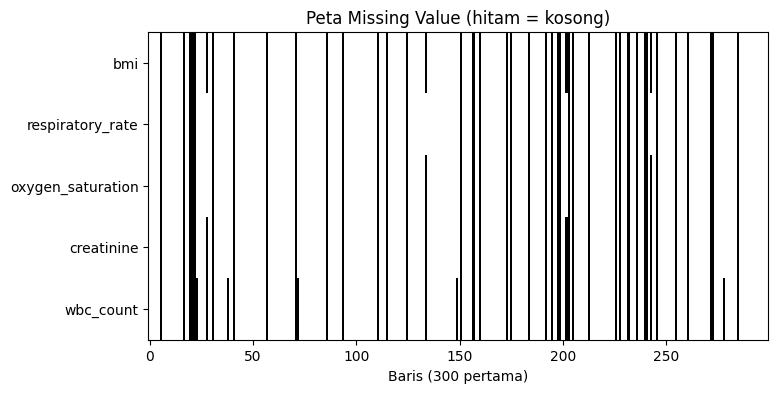

In [8]:
# Pola missing: apakah kolom-kolom itu kosong bersamaan?
MISS_COLS = ["bmi", "respiratory_rate", "oxygen_saturation", "creatinine", "wbc_count"]

print("Jumlah kolom kosong per baris (dari 5 kolom di atas):")
print(df[MISS_COLS].isna().sum(axis=1).value_counts().sort_index())

plt.figure(figsize=(8, 4))
plt.imshow(df[MISS_COLS].isna().values[:300].T, aspect="auto", cmap="gray_r", interpolation="nearest")
plt.yticks(range(len(MISS_COLS)), MISS_COLS)
plt.xlabel("Baris (300 pertama)")
plt.title("Peta Missing Value (hitam = kosong)")
plt.show()

In [9]:
# Apakah missing berhubungan dengan target?
for c in MISS_COLS:
    rate = df.groupby(df[c].isna())["survived_icu"].mean().round(3)
    print(f"{c:20s} survived rate | ada nilai: {rate[False]} | kosong: {rate[True]}")

bmi                  survived rate | ada nilai: 0.646 | kosong: 0.628
respiratory_rate     survived rate | ada nilai: 0.646 | kosong: 0.624
oxygen_saturation    survived rate | ada nilai: 0.647 | kosong: 0.624
creatinine           survived rate | ada nilai: 0.646 | kosong: 0.63
wbc_count            survived rate | ada nilai: 0.646 | kosong: 0.634


**Temuan:** ada baris yang kelima kolom tersebut kosong sekaligus (missing berkelompok). Rasio survival pada baris kosong dan tidak kosong hampir sama, jadi missing relatif acak (tidak sangat informatif terhadap target).

### 3.2 Duplikat

In [10]:
feature_cols = [c for c in df.columns if c not in ["patient_id", "survived_icu"]]

print("Duplikat patient_id            :", df["patient_id"].duplicated().sum())
print("Duplikat baris penuh           :", df.duplicated().sum())
print("Duplikat fitur+target (tanpa ID):", df.duplicated(subset=feature_cols + ["survived_icu"]).sum())

Duplikat patient_id            : 0
Duplikat baris penuh           : 0
Duplikat fitur+target (tanpa ID): 58


**Temuan:** tidak ada ID ganda, tetapi ada baris yang isinya identik jika kolom `patient_id` diabaikan (kemungkinan data pasien yang tercatat dua kali dengan ID berbeda).

### 3.3 Outlier

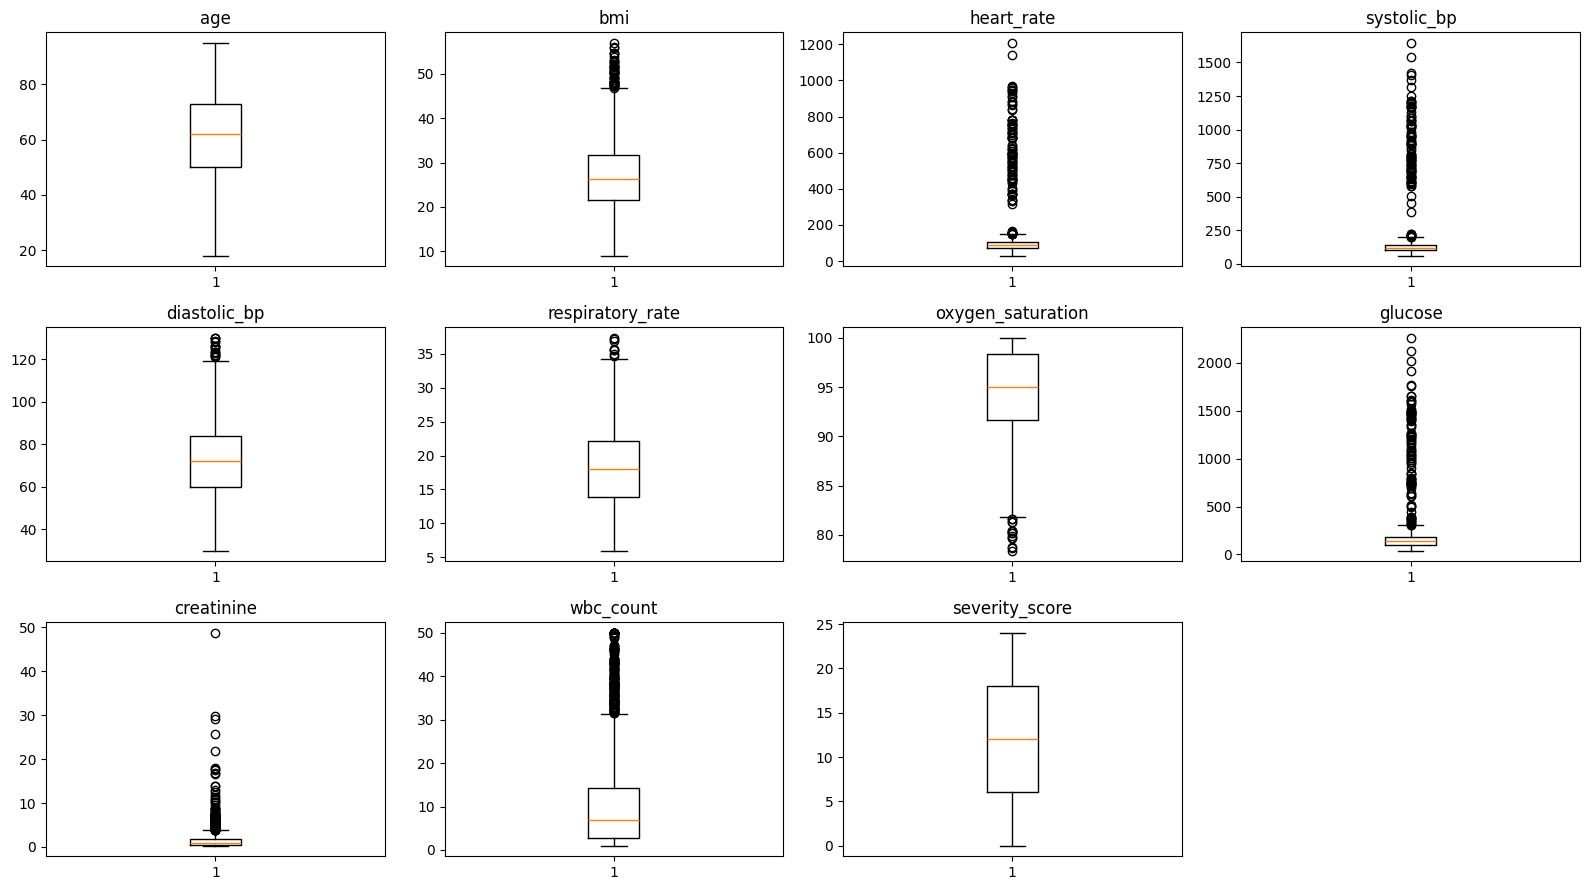

In [11]:
NUM_COLS = ["age", "bmi", "heart_rate", "systolic_bp", "diastolic_bp", "respiratory_rate",
            "oxygen_saturation", "glucose", "creatinine", "wbc_count", "severity_score"]

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, c in zip(axes.ravel(), NUM_COLS):
    ax.boxplot(df[c].dropna(), vert=True)
    ax.set_title(c)
for ax in axes.ravel()[len(NUM_COLS):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# Hitung outlier dengan metode IQR + skewness
rows = []
for c in NUM_COLS:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum()
    rows.append({"kolom": c, "min": df[c].min(), "max": df[c].max(),
                 "outlier_IQR": n_out, "skewness": round(df[c].skew(), 2)})
pd.DataFrame(rows).set_index("kolom")

,min,max,outlier_IQR,skewness
kolom,,,,
age,18.0,95.000000,0,-0.12
bmi,9.0,57.000000,47,0.51
heart_rate,30.0,1207.839980,106,7.28
systolic_bp,60.0,1645.595945,101,7.23
diastolic_bp,30.0,130.000000,16,0.04
respiratory_rate,6.0,37.300000,8,0.12
oxygen_saturation,78.4,100.000000,15,-0.60
glucose,40.0,2256.210085,95,6.94
creatinine,0.3,48.737770,198,9.16


**Temuan:** `heart_rate`, `systolic_bp`, `glucose`, dan `creatinine` punya nilai ekstrem yang tidak masuk akal secara medis (misal denyut jantung > 1000 bpm) dan distribusinya sangat miring (skewness tinggi).

### 3.4 Nilai Tidak Logis (Validasi Domain)

In [13]:
# Rentang fisiologis yang masuk akal (domain knowledge)
RANGES = {
    "age":               (18, 100),
    "bmi":               (12, 60),
    "heart_rate":        (30, 220),
    "systolic_bp":       (60, 250),
    "diastolic_bp":      (30, 150),
    "respiratory_rate":  (5, 60),
    "oxygen_saturation": (50, 100),
    "glucose":           (30, 600),
    "creatinine":        (0.1, 15),
    "wbc_count":         (0.5, 60),
}

rows = []
for c, (lo, hi) in RANGES.items():
    n = ((df[c] < lo) | (df[c] > hi)).sum()
    rows.append({"kolom": c, "rentang_valid": f"{lo} - {hi}", "baris_di_luar_rentang": n})
print(pd.DataFrame(rows).set_index("kolom"))

print("\nBaris dengan diastolic_bp >= systolic_bp (tidak logis):",
      (df["diastolic_bp"] >= df["systolic_bp"]).sum())

                  rentang_valid  baris_di_luar_rentang
kolom                                                 
age                    18 - 100                      0
bmi                     12 - 60                     33
heart_rate             30 - 220                     92
systolic_bp            60 - 250                     92
diastolic_bp           30 - 150                      0
respiratory_rate         5 - 60                      0
oxygen_saturation      50 - 100                      0
glucose                30 - 600                     79
creatinine             0.1 - 15                     10
wbc_count              0.5 - 60                      0

Baris dengan diastolic_bp >= systolic_bp (tidak logis): 346


### 3.5 Capping / Censoring

In [14]:
print("oxygen_saturation == 100 :", (df["oxygen_saturation"] == 100).sum(), "baris")
print("oxygen_saturation > 100  :", (df["oxygen_saturation"] > 100).sum(), "baris")

oxygen_saturation == 100 : 661 baris
oxygen_saturation > 100  : 0 baris


**Temuan:** banyak nilai saturasi oksigen tepat 100, yaitu batas atas alat ukur (censoring). Nilai ini valid, jadi tidak dihapus, tetapi perlu disadari saat interpretasi.

### Ringkasan Masalah

| No | Jenis masalah | Kolom terdampak | Strategi |
|----|---------------|-----------------|----------|
| 1 | Missing value (berkelompok) | bmi, respiratory_rate, oxygen_saturation, creatinine, wbc_count | Imputasi KNN + kolom indikator missing |
| 2 | Duplikat (selain ID) | semua fitur | Hapus duplikat pada data latih |
| 3 | Outlier ekstrem / mustahil | heart_rate, systolic_bp, glucose, creatinine, bmi | Nilai di luar rentang valid diubah jadi NaN lalu diimputasi |
| 4 | Nilai tidak logis | diastolic_bp >= systolic_bp | Keduanya diubah jadi NaN lalu diimputasi |
| 5 | Distribusi miring | glucose, creatinine, wbc_count | Transformasi log1p |
| 6 | Outlier sisa | semua numerik | Winsorizing persentil 1%-99% |
| 7 | Skala beda-beda | semua numerik | StandardScaler |

## 4. Split Data & Baseline pada Data Kotor

Data dibagi **sebelum** preprocessing yang bersifat belajar dari data (imputasi, scaling, winsorizing) supaya tidak terjadi *data leakage*. Test set yang sama dipakai untuk membandingkan model sebelum dan sesudah preprocessing.

In [15]:
X = df.drop(columns=["patient_id", "survived_icu"])
y = df["survived_icu"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (3664, 14) | Test: (916, 14)


In [16]:
def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    }

def evaluate(pipe, Xtr, ytr, Xte, yte):
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)[:, 1]
    return {
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1": f1_score(yte, pred),
        "ROC-AUC": roc_auc_score(yte, proba),
    }, pred

In [17]:
# BASELINE: data kotor, hanya diimputasi median supaya model bisa jalan (tanpa penanganan lain)
baseline_results = {}
baseline_preds = {}
for name, model in get_models().items():
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("model", model)])
    baseline_results[name], baseline_preds[name] = evaluate(pipe, X_train, y_train, X_test, y_test)

baseline_df = pd.DataFrame(baseline_results).T.round(4)
print("Majority-class baseline accuracy:", round(y_test.value_counts(normalize=True).max(), 4))
baseline_df

Majority-class baseline accuracy: 0.6441


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.6769,0.6870,0.9153,0.7849,0.6729
Random Forest,0.6692,0.6823,0.9102,0.7800,0.6688
Gradient Boosting,0.6627,0.6827,0.8898,0.7726,0.6528


## 5. Data Cleaning & Preprocessing

Dibagi dua tahap:
1. **Aturan berbasis domain** (per baris, tidak belajar dari data, jadi aman dilakukan sebelum split): nilai di luar rentang valid menjadi NaN, tekanan darah tidak logis menjadi NaN, serta penambahan fitur indikator missing.
2. **Pipeline sklearn** (belajar dari data latih saja): log transform, winsorizing, scaling, imputasi KNN.

In [18]:
def rule_based_clean(data):
    d = data.copy()

    # 1) nilai di luar rentang fisiologis -> NaN
    for c, (lo, hi) in RANGES.items():
        d.loc[(d[c] < lo) | (d[c] > hi), c] = np.nan

    # 2) diastolic >= systolic tidak logis -> keduanya NaN
    bad_bp = d["diastolic_bp"] >= d["systolic_bp"]
    d.loc[bad_bp, ["systolic_bp", "diastolic_bp"]] = np.nan

    # 3) fitur indikator missing (informasi bahwa data tidak tercatat)
    for c in MISS_COLS:
        d[f"{c}_missing"] = d[c].isna().astype(int)
    d["n_missing"] = d[MISS_COLS].isna().sum(axis=1)
    return d


X_train_c = rule_based_clean(X_train)
X_test_c = rule_based_clean(X_test)

# Sisa missing setelah aturan domain
before = X_train[NUM_COLS].isna().sum()
after = X_train_c[NUM_COLS].isna().sum()
pd.DataFrame({"missing_sebelum": before, "missing_sesudah": after})

,missing_sebelum,missing_sesudah
age,0,0
bmi,492,520
heart_rate,0,77
systolic_bp,0,353
diastolic_bp,0,276
respiratory_rate,456,456
oxygen_saturation,479,479
glucose,0,64
creatinine,507,516
wbc_count,635,635


In [19]:
# Hapus duplikat HANYA pada data latih (test set dibiarkan apa adanya)
train_c = pd.concat([X_train_c, y_train], axis=1)
n_before = len(train_c)
train_c = train_c.drop_duplicates(subset=X.columns.tolist())
print(f"Data latih: {n_before} -> {len(train_c)} baris ({n_before - len(train_c)} duplikat dihapus)")

X_train_c = train_c.drop(columns=["survived_icu"])
y_train_c = train_c["survived_icu"]

Data latih: 3664 -> 3627 baris (37 duplikat dihapus)


In [20]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """Clip tiap kolom ke persentil bawah/atas yang dihitung dari data latih."""
    def __init__(self, lower=1, upper=99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_ = np.nanpercentile(X, self.lower, axis=0)
        self.hi_ = np.nanpercentile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lo_, self.hi_)


SKEWED = ["glucose", "creatinine", "wbc_count"]

def make_preprocessor():
    log_step = ColumnTransformer(
        [("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), SKEWED)],
        remainder="passthrough",
    )
    return Pipeline([
        ("log", log_step),                    # kurangi kemiringan
        ("winsor", Winsorizer(1, 99)),        # potong outlier sisa
        ("scale", StandardScaler()),          # samakan skala
        ("impute", KNNImputer(n_neighbors=5)) # isi missing dari tetangga terdekat
    ])

## 6. Modeling Setelah Preprocessing

In [21]:
clean_results = {}
clean_preds = {}
for name, model in get_models().items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", model)])
    clean_results[name], clean_preds[name] = evaluate(pipe, X_train_c, y_train_c, X_test_c, y_test)

clean_df = pd.DataFrame(clean_results).T.round(4)
clean_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.6747,0.6881,0.9051,0.7818,0.6740
Random Forest,0.6616,0.6790,0.9000,0.7741,0.6622
Gradient Boosting,0.6539,0.6766,0.8864,0.7674,0.6539


## 7. Perbandingan Sebelum vs Sesudah Preprocessing

In [22]:
comparison = pd.concat(
    {"Sebelum (data kotor)": baseline_df, "Sesudah (preprocessing)": clean_df}, axis=1
)
comparison

Sebelum (data kotor)                                   Sesudah (preprocessing)                                  
                                Accuracy Precision  Recall      F1 ROC-AUC                Accuracy Precision  Recall      F1 ROC-AUC
Logistic Regression               0.6769    0.6870  0.9153  0.7849  0.6729                  0.6747    0.6881  0.9051  0.7818  0.6740
Random Forest                     0.6692    0.6823  0.9102  0.7800  0.6688                  0.6616    0.6790  0.9000  0.7741  0.6622
Gradient Boosting                 0.6627    0.6827  0.8898  0.7726  0.6528                  0.6539    0.6766  0.8864  0.7674  0.6539

                     Sebelum  Sesudah  Selisih
Logistic Regression   0.6769   0.6747  -0.0022
Random Forest         0.6692   0.6616  -0.0076
Gradient Boosting     0.6627   0.6539  -0.0088


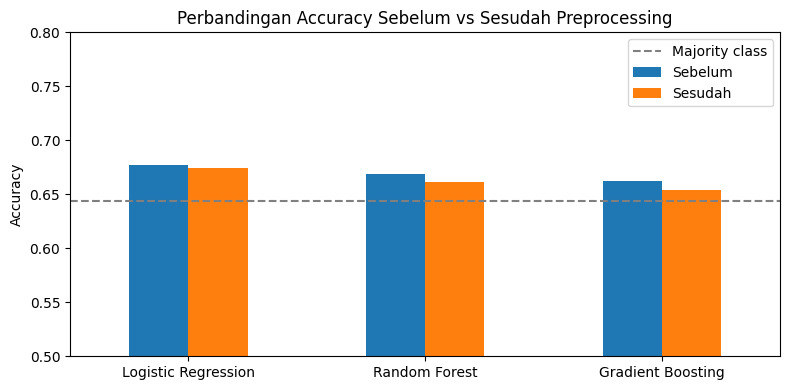

In [23]:
acc_cmp = pd.DataFrame({
    "Sebelum": baseline_df["Accuracy"],
    "Sesudah": clean_df["Accuracy"],
})
acc_cmp["Selisih"] = (acc_cmp["Sesudah"] - acc_cmp["Sebelum"]).round(4)
print(acc_cmp)

acc_cmp[["Sebelum", "Sesudah"]].plot(kind="bar", figsize=(8, 4), ylim=(0.5, 0.8))
plt.axhline(y_test.value_counts(normalize=True).max(), color="gray", linestyle="--", label="Majority class")
plt.title("Perbandingan Accuracy Sebelum vs Sesudah Preprocessing")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

Model terbaik: Logistic Regression


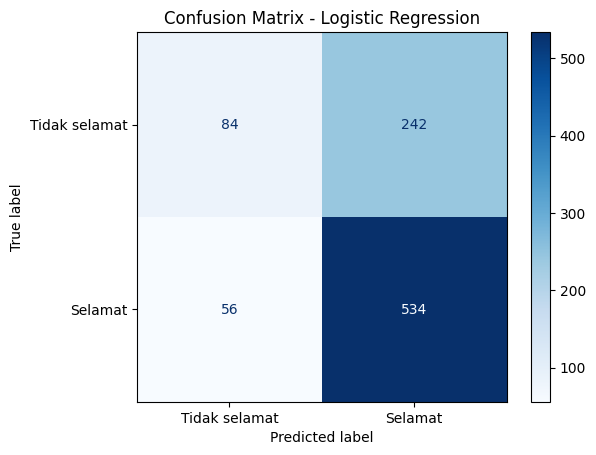

In [24]:
# Confusion matrix model terbaik (berdasarkan accuracy) setelah preprocessing
best = clean_df["Accuracy"].idxmax()
print("Model terbaik:", best)
ConfusionMatrixDisplay(confusion_matrix(y_test, clean_preds[best]),
                       display_labels=["Tidak selamat", "Selamat"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best}")
plt.show()

## 8. Validasi Lebih Stabil dengan Cross-Validation

Hasil pada satu kali split bisa kebetulan. Berikut 5-fold stratified CV (preprocessing berada di dalam pipeline, jadi tetap bebas leakage).

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_rule = rule_based_clean(X)  # aturan domain bersifat per baris, aman dipakai sebelum CV

rows = []
for name, model in get_models().items():
    raw_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("model", model)])
    cln_pipe = Pipeline([("prep", make_preprocessor()), ("model", model)])
    s_raw = cross_val_score(raw_pipe, X, y, cv=skf, scoring="accuracy")
    s_cln = cross_val_score(cln_pipe, X_rule, y, cv=skf, scoring="accuracy")
    rows.append({"Model": name,
                 "CV acc sebelum": f"{s_raw.mean():.4f} +/- {s_raw.std():.4f}",
                 "CV acc sesudah": f"{s_cln.mean():.4f} +/- {s_cln.std():.4f}"})
pd.DataFrame(rows).set_index("Model")

,CV acc sebelum,CV acc sesudah
Model,,
Logistic Regression,0.6692 +/- 0.0115,0.6655 +/- 0.0124
Random Forest,0.6703 +/- 0.0108,0.6675 +/- 0.0115
Gradient Boosting,0.6579 +/- 0.0118,0.6515 +/- 0.0093


## 9. Kesimpulan

*(Sesuaikan angka dengan output yang kamu dapat saat menjalankan notebook.)*

- Dataset ICU ini mengandung beberapa jenis kekotoran sekaligus: missing value berkelompok, outlier ekstrem yang mustahil secara medis, tekanan darah tidak logis, duplikat tersembunyi (selain ID), dan capping pada saturasi oksigen.
- Preprocessing dilakukan dengan aturan domain, transformasi log, winsorizing, scaling, dan imputasi KNN dalam satu pipeline sehingga tidak ada data leakage.
- Accuracy sebelum dan sesudah preprocessing hampir sama (selisih sekitar 1 poin persentase, bahkan sedikit turun pada Random Forest dan Gradient Boosting), dan semuanya hanya sedikit di atas baseline kelas mayoritas (~64%). Selisih sekecil ini masih dalam rentang variasi antar-fold CV, jadi tidak bisa disebut perbaikan atau penurunan yang nyata.
- Penyebabnya: kolom yang kotor (heart_rate, systolic_bp, glucose, creatinine, wbc_count, bmi) hampir tidak berkorelasi dengan target, sedangkan sinyal prediktif ada di kolom yang relatif bersih (age, severity_score, ventilation_required, chronic_conditions). Nilai ekstrem di kolom-kolom itu adalah noise, sehingga membersihkannya membuat data lebih valid tetapi tidak menaikkan accuracy. Model berbasis pohon juga sudah cukup tahan terhadap outlier dan skala.
- Preprocessing tetap penting karena membuat data valid secara domain (tidak ada denyut jantung > 220, tekanan diastolik tidak melebihi sistolik) dan pipeline-nya siap dipakai pada data baru. Recall tinggi (~0,9) dengan precision ~0,68 menunjukkan model cenderung memprediksi "selamat" karena kelas tidak seimbang, jadi F1 dan ROC-AUC perlu dilihat bersama accuracy.